In [26]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from pathlib import Path
from matplotlib.lines import Line2D
import os
import pandas as pd
from matplotlib_map_utils import ScaleBar, scale_bar # also valid
from matplotlib.patches import Patch
from pyproj import Transformer
import numpy as np




# --- Folde paths
base_folder = Path.cwd().parents[1]  # go up from /code/analysis/ → project root
data_folder = base_folder / "data"
figures_folder = base_folder / "output/figures"



In [7]:

# --- Read spatial layers ---
case_zones = gpd.read_file(data_folder / "Case_Zones.gpkg")
control_zones = gpd.read_file(data_folder / "Control_Zones.gpkg") # Zones without outbreak
negative_control_zones = gpd.read_file(data_folder / "Negative_Control_Zones.gpkg") # Zones without outbreak, but containing a feedlot/farm

# --- Project to Web Mercator for basemap ---
case_zones = case_zones.to_crs(epsg=3857)
control_zones = control_zones.to_crs(epsg=3857)
negative_control_zones = negative_control_zones.to_crs(epsg=3857)


In [22]:
# Count number of case zones, control zones, and negative control zones
num_case_zones = case_zones['zone_id'].nunique()
num_control_zones = control_zones['zone_id'].nunique()
num_negative_control_zones = negative_control_zones['zone_id'].nunique()
num_all_zones = num_case_zones + num_control_zones + num_negative_control_zones

print(f"Number of case zones: {num_case_zones}")
print(f"Number of control zones: {num_control_zones}")
print(f"Number of negative control zones: {num_negative_control_zones}")
print(f"Total number of zones: {num_all_zones}")


Number of case zones: 77
Number of control zones: 3257
Number of negative control zones: 2065
Total number of zones: 5399


## BASIC PLOT

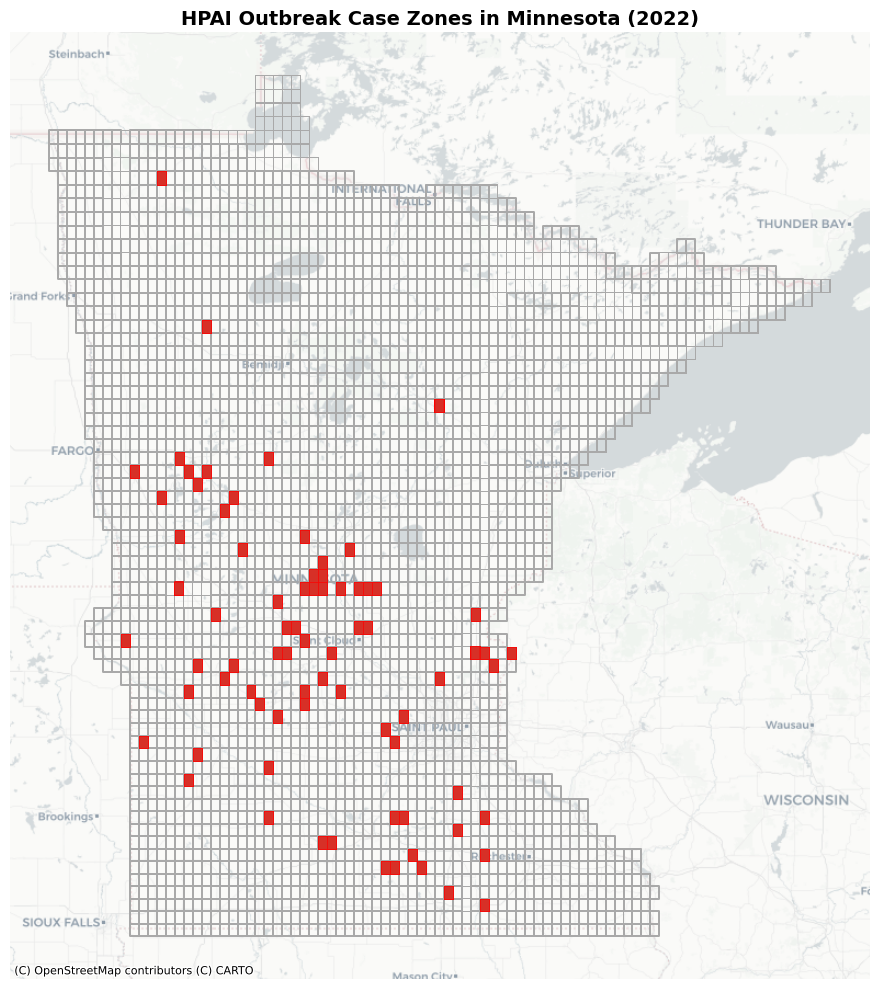

In [3]:

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 10))
control_zones.plot(ax=ax, facecolor='none', edgecolor='darkgrey', linewidth=0.2)
case_zones.plot(ax=ax, facecolor='#d73027', edgecolor='red', linewidth=0.4, alpha=0.9)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs=case_zones.crs)

ax.set_title("HPAI Outbreak Case Zones in Minnesota (2022)", fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig(base_folder / "case_zones_mn.png", dpi=300)
plt.show()




## MORE PRESENTABLE PLOT VERSION 

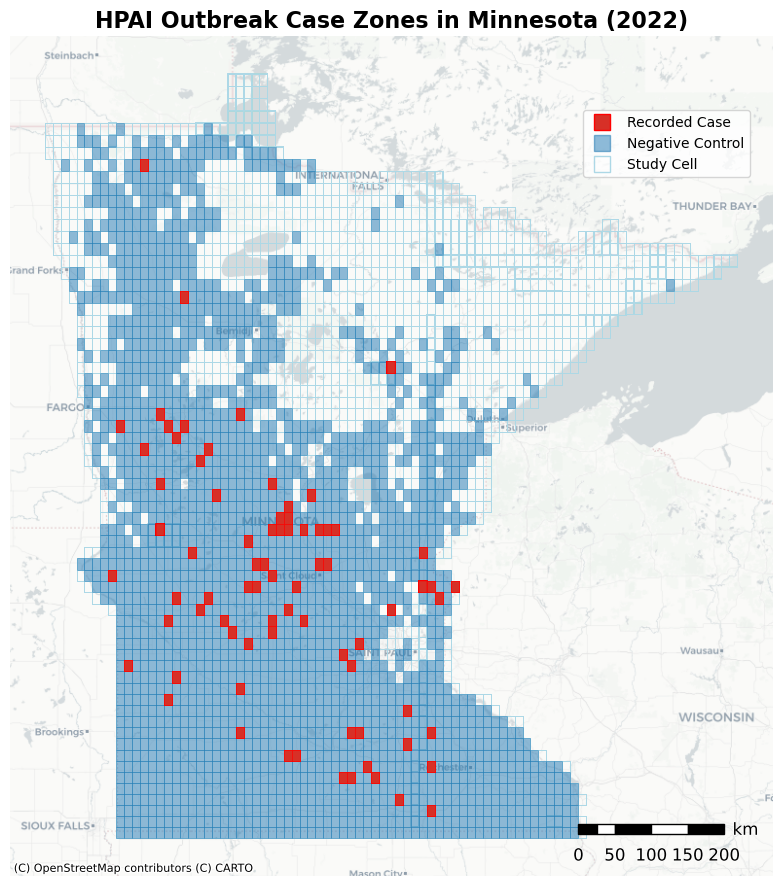

In [ ]:
# Plot
fig, ax = plt.subplots(figsize=(10, 10))

# Plot control zones
control_zones.plot(ax=ax, facecolor='none', edgecolor='lightblue', linewidth=0.4)

# Plot negative control zones
negative_control_zones.plot(ax=ax, facecolor='#1f78b4', edgecolor="#1270ae", 
                            linewidth=0.4, alpha=0.5)
# Plot case zones
case_zones.plot(ax=ax, facecolor='#d73027', edgecolor='red', linewidth=0.4, alpha=0.9)

# Add basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs=case_zones.crs)

# --- Add scale bar ---
scale_bar(ax=ax, location="lower right", style="boxes", bar={"projection":3857, "length":1.5, "unit":"km"}, labels = {"style":"major", "loc":"below"})

# Add title
ax.set_title("HPAI Outbreak Case Zones in Minnesota (2022)", fontsize=16, fontweight='bold')

# Custom legend using proxy artists
legend_elements = [
    Line2D([0], [0], color='red', marker='s', markersize=12, linestyle='None', 
           markerfacecolor='#d73027', label='Positive Case'),
    Line2D([0], [0], color='#1270ae', marker='s', markersize=12, linestyle='None',
           markerfacecolor='#1f78b4', alpha=0.5, label='Negative Control'),
    Line2D([0], [0], color='lightblue', marker='s', markersize=12, fillstyle='none',
           linestyle='None', label='Study Cell')
]
ax.legend(
    handles=legend_elements,
    loc='upper right',
    frameon=True,
    bbox_to_anchor=(0.98, 0.92)  # slightly down and inward
)
# Tidy layout
ax.axis('off')
plt.subplots_adjust(top=0.92, bottom=0.08)

# Save or show
plt.savefig(figures_folder / "case_zones_mn_present_version.png", 
            dpi=300, bbox_inches='tight')
plt.show()

## MANUSCRIPT VERSION (GREY)

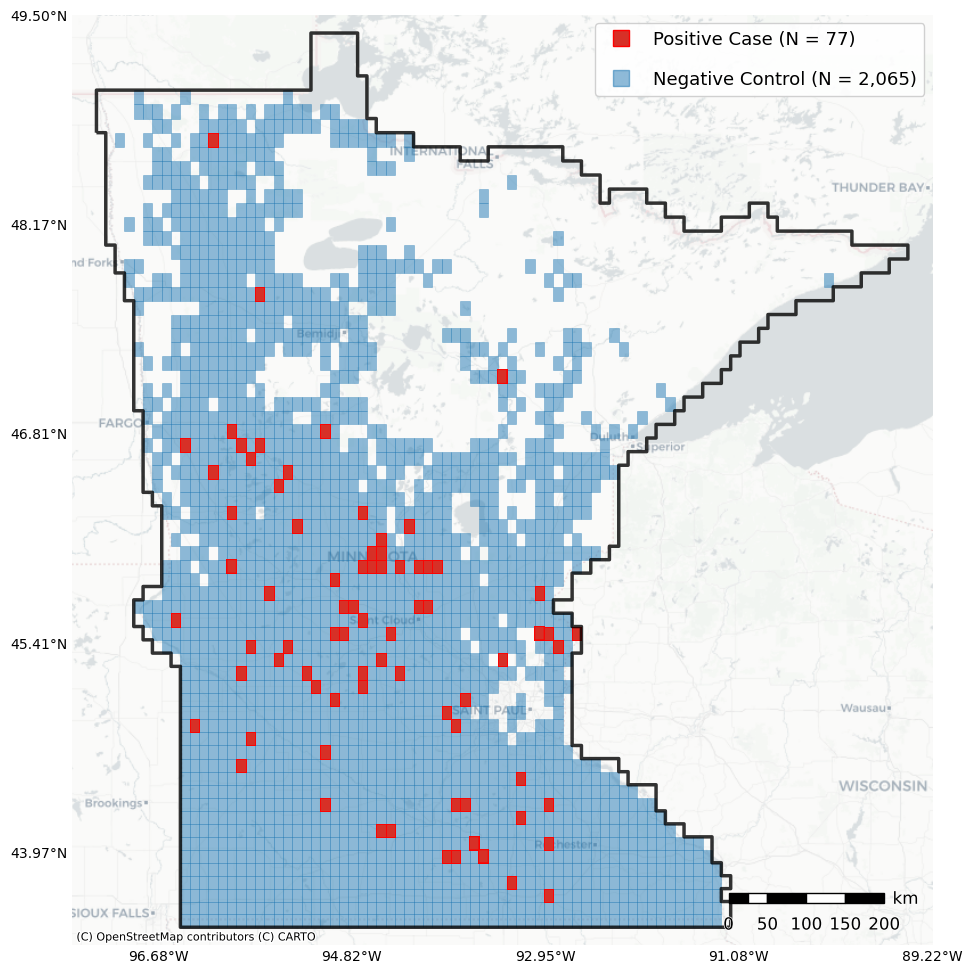

In [36]:
# --- Dissolve to get border ---
study_area = gpd.GeoDataFrame(pd.concat([case_zones, control_zones], ignore_index=True))
study_outline = study_area.dissolve()  # unified "Study Area" outline

# --- Plot setup ---A
fig, ax = plt.subplots(figsize=(10, 10))

# Plot control zones (those without an outbreak and not containing a feedlot/farm)
#control_zones.plot(ax=ax, facecolor='none', edgecolor='lightblue', linewidth=0.4)

# Plot negative control zones
negative_control_zones.plot(ax=ax, facecolor='#1f78b4', edgecolor
                            ="#1270ae", linewidth=0.4, alpha=0.5)

# Plot case zones (recorded cases)
case_zones.plot(ax=ax, facecolor='#d73027', edgecolor='red', linewidth=0.6, alpha=0.9)

# Add basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs=case_zones.crs, alpha=0.85)

# Overlay “Study Area” outline
study_outline.boundary.plot(ax=ax, edgecolor='black', linewidth=2.5, alpha=0.8)

# --- Add scale bar ---
scale_bar(ax=ax, location="lower right", style="boxes", bar={"projection":3857, "length":1.5, "unit":"km"}, labels = {"style":"major", "loc":"below"})


# --- Custom legend ---
legend_elements = [
    Line2D([0], [0], color='red', marker='s', markersize=12, linestyle='None', 
           markerfacecolor='#d73027', label='Positive Case (N = 77)'),
    Line2D([0], [0], color='#1270ae', marker='s', markersize=12, linestyle='None',
           markerfacecolor='#1f78b4', alpha=0.5, label='Negative Control (N = 2,065)')
]


ax.legend(
    handles=legend_elements,
    loc='upper right',
    bbox_to_anchor=(0.995, 0.995),  
    borderaxespad=0.2,              
    frameon=True,
    fontsize=13,
    framealpha=0.9,
    labelspacing=1.2,
)

# --- Adjust map extent ---
# Add a small padding factor around the geometries for better framing
xmin, ymin, xmax, ymax = study_outline.total_bounds
pad_x = (xmax - xmin) * 0.03  # 3% horizontal padding
pad_y = (ymax - ymin) * 0.02  # 2% vertical padding

ax.set_xlim(xmin - pad_x, xmax + pad_x)
ax.set_ylim(ymin - pad_y, ymax + pad_y)

#--- Add lat/lon tick labels ---
transformer = Transformer.from_crs(case_zones.crs, "EPSG:4326", always_xy=True)

# Get current extent
xmin_ax, xmax_ax = ax.get_xlim()
ymin_ax, ymax_ax = ax.get_ylim()

# Create tick positions
x_ticks = np.linspace(xmin_ax + (xmax_ax - xmin_ax) * 0.1, xmax_ax, 5)
y_ticks = np.linspace(ymin_ax + (ymax_ax - ymin_ax) * 0.1, ymax_ax, 5)

# Convert to lat/lon labels
x_labels = [f"{abs(transformer.transform(x, ymin_ax)[0]):.2f}°W" for x in x_ticks]
y_labels = [f"{transformer.transform(xmin_ax, y)[1]:.2f}°N" for y in y_ticks]

ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, fontsize=10)
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels, fontsize=10)

# Style: remove spines, keep tick labels
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(axis='both', length=0)

# --- Final layout ---
plt.subplots_adjust(left=0.08, right=0.98, top=0.98, bottom=0.05)

# --- Save high-res figure ---
plt.savefig(figures_folder / "case_zones_map_grey.png",
            dpi=600, bbox_inches='tight', pad_inches=0.1)
plt.show()


## MANUSCRIPT VERSION (VEG)

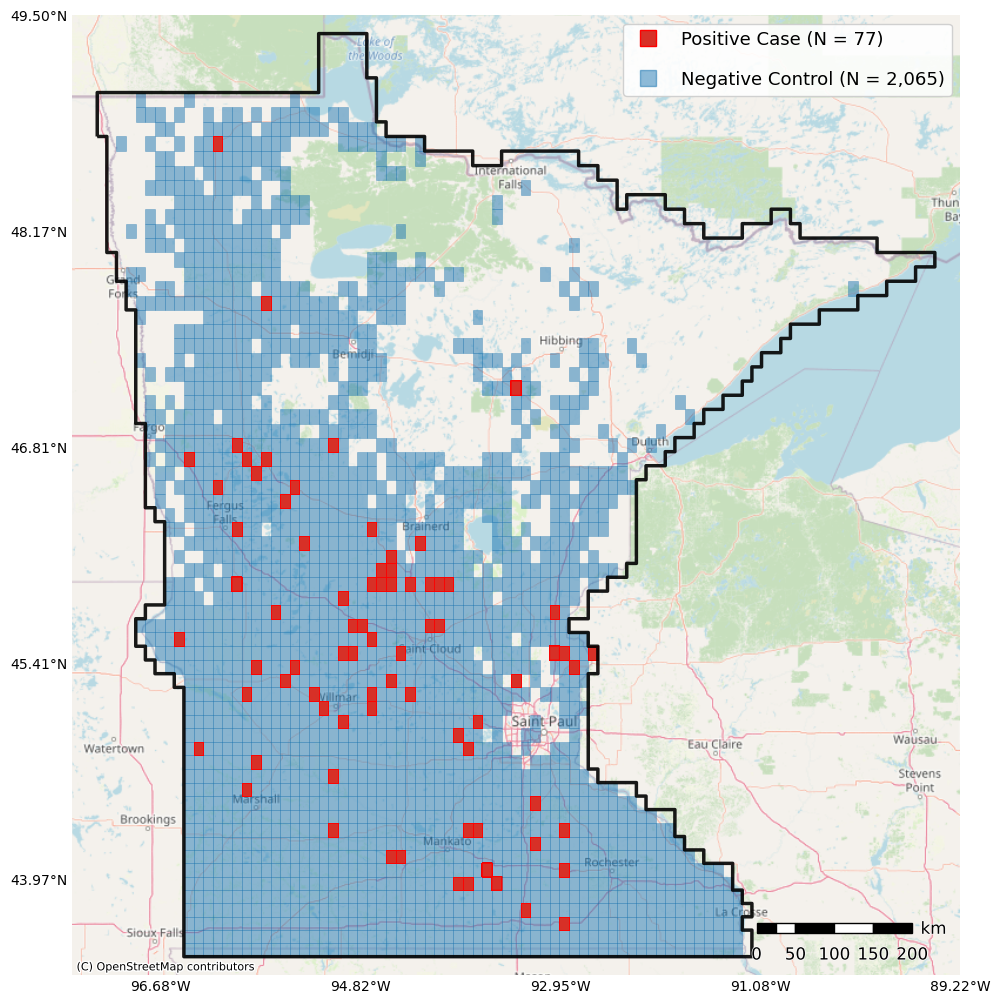

In [35]:
# --- Plot setup ---
fig, ax = plt.subplots(figsize=(10, 10))

# Plot control zones (negative areas)
#control_zones.plot(ax=ax, facecolor='none', edgecolor='lightblue', linewidth=0.4)

# Plot negative control zones
negative_control_zones.plot(ax=ax, facecolor='#1f78b4', edgecolor
                            ="#1270ae", linewidth=0.4, alpha=0.5)

# Plot case zones (recorded cases)
case_zones.plot(ax=ax, facecolor='#d73027', edgecolor='red', linewidth=0.6, alpha=0.9)

# --- Add greener basemap ---
ctx.add_basemap(
    ax,
    source=ctx.providers.OpenStreetMap.Mapnik,  # greener & terrain detail
    crs=case_zones.crs,
    alpha=0.85
)

# --- Overlay “Study Area” outline ---
study_outline.boundary.plot(ax=ax, edgecolor='black', linewidth=2.5, alpha=0.9)

# --- Add scale bar ---
scale_bar(ax=ax, location="lower right", style="boxes", bar={"projection":3857, "length":1.5, "unit":"km"}, labels = {"style":"major", "loc":"below"})

# --- Custom legend ---
legend_elements = [
    Line2D([0], [0], color='red', marker='s', markersize=12, linestyle='None', 
           markerfacecolor='#d73027', label='Positive Case (N = 77)'),
    Line2D([0], [0], color='#1270ae', marker='s', markersize=12, linestyle='None',
           markerfacecolor='#1f78b4', alpha=0.5, label='Negative Control (N = 2,065)')
]


ax.legend(
    handles=legend_elements,
    loc='upper right',
    bbox_to_anchor=(0.995, 0.995),  
    borderaxespad=0.2,              
    frameon=True,
    fontsize=13,
    framealpha=0.9,
    labelspacing=1.2,
)


# --- Adjust map extent ---
# Add a small padding factor around the geometries for better framing
xmin, ymin, xmax, ymax = study_outline.total_bounds
pad_x = (xmax - xmin) * 0.03  # 3% horizontal padding
pad_y = (ymax - ymin) * 0.02  # 2% vertical padding

ax.set_xlim(xmin - pad_x, xmax + pad_x)
ax.set_ylim(ymin - pad_y, ymax + pad_y)

#--- Add lat/lon tick labels ---
transformer = Transformer.from_crs(case_zones.crs, "EPSG:4326", always_xy=True)

# Get current extent
xmin_ax, xmax_ax = ax.get_xlim()
ymin_ax, ymax_ax = ax.get_ylim()

# Create tick positions
x_ticks = np.linspace(xmin_ax + (xmax_ax - xmin_ax) * 0.1, xmax_ax, 5)
y_ticks = np.linspace(ymin_ax + (ymax_ax - ymin_ax) * 0.1, ymax_ax, 5)

# Convert to lat/lon labels
x_labels = [f"{abs(transformer.transform(x, ymin_ax)[0]):.2f}°W" for x in x_ticks]
y_labels = [f"{transformer.transform(xmin_ax, y)[1]:.2f}°N" for y in y_ticks]

ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, fontsize=10)
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels, fontsize=10)

# Style: remove spines, keep tick labels
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(axis='both', length=0)


# --- Final layout ---
plt.subplots_adjust(left=0.02, right=0.98, top=0.98, bottom=0.02)

# --- Save high-res figure ---
plt.savefig(figures_folder / "case_zones_map_veg.png",
            dpi=600, bbox_inches='tight', pad_inches=0)
plt.show()


## COUNT CASES AND CONTROL ZONES

In [34]:
# Subset to week == 1
case_week1 = case_zones[case_zones["week"] == 1]
control_week1 = control_zones[control_zones["week"] == 1]

# Count the number of zones
n_case_week1 = len(case_week1)
n_control_week1 = len(control_week1)

print(f"Number of case zones in week 1: {n_case_week1}")
print(f"Number of control zones in week 1: {n_control_week1}")


Number of case zones in week 1: 77
Number of control zones in week 1: 3257
